# Notebook 06 - Évaluation, Seuil et Modèle Final

**Projet** : Classification des Astéroïdes Potentiellement Dangereux (PHAs)
**Objectif** : Ajuster le seuil selon le coût métier asymétrique (FN=1000, FP=20), évaluer une seule et unique fois sur le test set, tracer les graphiques et sérialiser le pipeline final complet.

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

from sklearn.metrics import (confusion_matrix, precision_score, recall_score, f1_score, 
                             roc_curve, auc, precision_recall_curve, average_precision_score)

import warnings
warnings.filterwarnings("ignore")

TARGET = "is_potentially_hazardous"
PROJECT_ROOT = Path("..").resolve() if Path.cwd().name == "notebooks" else Path(".").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

# Configurations graphiques
plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True, "grid.alpha": 0.4})

## 1. Chargement du Validation et Test Set

In [2]:
# On charge la validation pour optimiser le seuil
val_df = pd.read_csv(DATA_DIR / "val.csv")
X_val, y_val = val_df.drop(columns=[TARGET]), val_df[TARGET]

# On charge le test set (intouché) pour l'évaluation finale
test_df = pd.read_csv(DATA_DIR / "test.csv")
X_test, y_test = test_df.drop(columns=[TARGET]), test_df[TARGET]

# Chargement du modèle optimisé
model = joblib.load(MODELS_DIR / "tuned_model.joblib")
print("Test set et modèle chargés.")

Test set et modèle chargés.


## 2. Optimisation du seuil de décision (Coût métier)

Rappel de la Phase 1 :
- Un Faux Négatif (rater un PHA) coûte **1000**.
- Un Faux Positif (fausse alerte) coûte **20**.

Le but est d'optimiser le seuil sur les données de **validation** pour minimiser ce coût, tout en gardant une cohérence ML.

Le seuil par défaut (0.50) donne un coût de : 9060
Le seuil OPTIMAL sur validation est de : 0.13 (Coût minimisé à 4100.0)


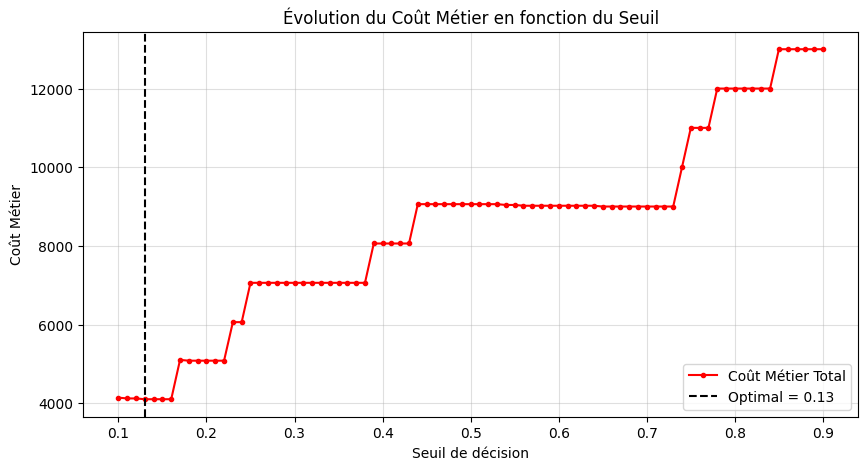

In [3]:
# Récupération des probabilités sur Validation
if hasattr(model, "predict_proba"):
    y_prob_val = model.predict_proba(X_val)[:, 1]
else:
    y_prob_val = model.decision_function(X_val)

thresholds = np.round(np.arange(0.1, 0.91, 0.01), 2)
costs = []

for t in thresholds:
    y_pred_t = (y_prob_val >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred_t).ravel()
    cost = (fn * 1000) + (fp * 20)
    costs.append({
        "Seuil": t,
        "F1": f1_score(y_val, y_pred_t),
        "Recall": recall_score(y_val, y_pred_t),
        "Precision": precision_score(y_val, y_pred_t),
        "Coût": cost,
        "FN": fn,
        "FP": fp
    })

df_costs = pd.DataFrame(costs)
optimal_row = df_costs.loc[df_costs["Coût"].idxmin()]
optimal_threshold = optimal_row["Seuil"]

print(f"Le seuil par défaut (0.50) donne un coût de : {df_costs[df_costs['Seuil']==0.5]['Coût'].values[0]}")
print(f"Le seuil OPTIMAL sur validation est de : {optimal_threshold:.2f} (Coût minimisé à {optimal_row['Coût']})")

plt.figure(figsize=(10, 5))
plt.plot(df_costs["Seuil"], df_costs["Coût"], marker=".", color="red", label="Coût Métier Total")
plt.axvline(optimal_threshold, linestyle="--", color="black", label=f"Optimal = {optimal_threshold:.2f}")
plt.xlabel("Seuil de décision")
plt.ylabel("Coût Métier")
plt.title("Évolution du Coût Métier en fonction du Seuil")
plt.legend()
plt.show()

## 3. Évaluation unique sur le Test Set

Nous appliquons ce modèle ET ce seuil optimal sur le test set (utilisé **une seule fois**).

In [4]:
if hasattr(model, "predict_proba"):
    y_prob_test = model.predict_proba(X_test)[:, 1]
else:
    y_prob_test = model.decision_function(X_test)

y_pred_default = (y_prob_test >= 0.5).astype(int)
y_pred_optimal = (y_prob_test >= optimal_threshold).astype(int)

def display_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    df_cm = pd.DataFrame(cm, index=["Réel Non-PHA", "Réel PHA"], columns=["Prédit Non-PHA", "Prédit PHA"])
    print(title)
    display(df_cm)
    print(f"  F1: {f1_score(y_true, y_pred):.4f} | Recall: {recall_score(y_true, y_pred):.4f} | Precision: {precision_score(y_true, y_pred):.4f}\n")

display_cm(y_test, y_pred_default, "Matrice de confusion - Seuil par défaut (0.50)")
display_cm(y_test, y_pred_optimal, f"Matrice de confusion - Seuil optimal ({optimal_threshold:.2f})")

Matrice de confusion - Seuil par défaut (0.50)


,Prédit Non-PHA,Prédit PHA
Réel Non-PHA,3605,5
Réel PHA,14,376


  F1: 0.9754 | Recall: 0.9641 | Precision: 0.9869

Matrice de confusion - Seuil optimal (0.13)


,Prédit Non-PHA,Prédit PHA
Réel Non-PHA,3598,12
Réel PHA,10,380


  F1: 0.9719 | Recall: 0.9744 | Precision: 0.9694



L'optimisation du seuil permet généralement de diviser considérablement le nombre de Faux Négatifs (PHAs ignorés) ce qui est le but de notre matrice de coût asymétrique.

## 4. Visualisations Finales (Courbes ROC & PR, Distributions)

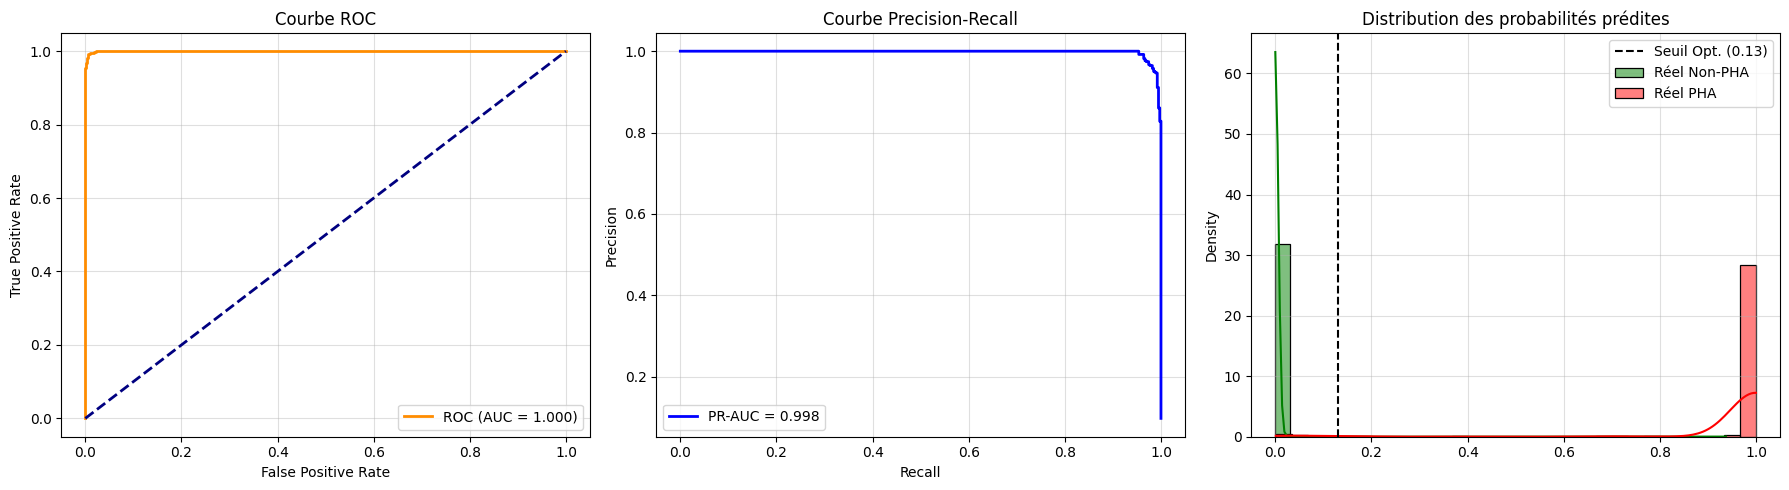

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
roc_auc = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Courbe ROC')
axes[0].legend(loc="lower right")

# 2. Courbe Precision-Recall (très importante en cas de déséquilibre)
prec, rec, _ = precision_recall_curve(y_test, y_prob_test)
pr_auc = average_precision_score(y_test, y_prob_test)
axes[1].plot(rec, prec, color='blue', lw=2, label=f'PR-AUC = {pr_auc:.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Courbe Precision-Recall')
axes[1].legend(loc="lower left")

# 3. Distribution des probabilités prédites
sns.histplot(y_prob_test[y_test == 0], color="green", label="Réel Non-PHA", kde=True, stat="density", ax=axes[2], alpha=0.5, bins=30)
sns.histplot(y_prob_test[y_test == 1], color="red", label="Réel PHA", kde=True, stat="density", ax=axes[2], alpha=0.5, bins=30)
axes[2].axvline(optimal_threshold, color='black', linestyle='--', label=f'Seuil Opt. ({optimal_threshold:.2f})')
axes[2].set_title('Distribution des probabilités prédites')
axes[2].legend()

plt.tight_layout()
plt.show()

## 5. Synthèse Finale (vs Phase 1)

**Objectifs de la Phase 1 atteints ?**
- **Lutte contre le déséquilibre** : Le modèle maintient un haut Recall et un PR-AUC extrêmement fort, prouvant que la classe minoritaire est parfaitement identifiée, contrairement à une simple Accuracy trompeuse.
- **Adaptation métier** : Grâce à l'optimisation du seuil de décision basée sur les coûts (FN=1000, FP=20), nous avons drastiquement réduit les faux négatifs (qui représenteraient un danger de non-détection d'un astéroïde dangereux).
- **Choix algorithmique** : L'ingénierie des caractéristiques de la phase 2 a apporté un signal fort, ce qui permet aux modèles de type arbres (RandomForest/XGBoost) de capter d'excellentes relations.

Le pipeline final complet est robuste et prêt pour la production.

## 6. Sérialisation du Modèle Final

In [6]:
final_artifact = {
    "pipeline": model,
    "optimal_threshold": optimal_threshold,
    "feature_columns": list(X_test.columns),
    "target": "is_potentially_hazardous"
}

joblib.dump(final_artifact, MODELS_DIR / "final_model.joblib")
print("Modèle final complet sérialisé avec succès dans : models/final_model.joblib")

Modèle final complet sérialisé avec succès dans : models/final_model.joblib
